In [ ]:
library(Seurat)
library(SeuratWrappers)
library(dplyr)
library(ggplot2)
library(usethis)
library(devtools)
library(harmony)
library(patchwork)
library(ggplot2)
library(gridExtra)
library(jcolors)
library(MetBrewer)
library(readxl)

# Libraries for pathway analysis

library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)



Warning message:
“package ‘Seurat’ was built under R version 4.5.2”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.5.2”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.5.2”
‘SeuratObject’ was built with package ‘Matrix’ 1.7.4 but the current
version is 1.7.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.5.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
Warning message:
“package ‘devtools’ was built under R version 4.5.2”
Loading required package: 

Warning message:
“package ‘clusterProfiler’ was built under R version 4.5.3”


clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Warning message:
“package ‘AnnotationDbi’ was built under R version 4.5.2”
Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGeneri

In [4]:
setwd("~/Documents/1 - Projects/Jain Lab/Morphodynamics paper/data")
timecourse <- readRDS("Timecourse.rds")

###  Only ECM-related marker genes per cell type

In [6]:
# Akansha's list
ecm_genes <- read_excel("~/Documents/1 - Projects/Jain Lab/Morphodynamics paper/data/presel_genes.xlsx", sheet = 2)
ecm_genes_list <- unique(na.omit(unlist(ecm_genes)))

# Your list
nick_ecm <- read_excel("/Users/nickmahtani/Documents/1 - Projects/Jain Lab/Mechanotransduction/data/ECM_Gene_Set_Curated.xlsx")
nick_ecm_genes <- unique(na.omit(nick_ecm$`Gene Symbol`))

# Combined
all_ecm_genes <- unique(c(ecm_genes_list, nick_ecm_genes))


In [26]:
Idents(timecourse) <- "class3"
cell_types <- unique(timecourse$class3)

all_markers <- list()

for (ct in cell_types) {
  markers <- FindMarkers(
    timecourse,
    ident.1 = ct,
    only.pos = TRUE,
    min.pct = 0.25,
    logfc.threshold = log(1.2)
  )
  
  markers$gene <- rownames(markers)
  
  all_markers[[ct]] <- markers %>%
    filter(gene %in% all_ecm_genes) %>%
    mutate(specificity = pct.1 / pct.2) %>%
    arrange(desc(specificity))
}


## Using DAVID for Gene Enrichment Analysis

In [86]:
go_dir <- "/Users/nickmahtani/Documents/1 - Projects/Jain Lab/Mechanotransduction/data/GO Tables"

files <- list.files(go_dir, pattern = "*.csv", full.names = TRUE)

plots <- list()

for (f in files) {
  # Extract cell type and BP/CC from filename
  fname <- basename(f)
  ct <- gsub("DAVIDChartReport_(.+)_2026-04-09.*\\.csv", "\\1", fname)
  type <- ifelse(grepl("-2", fname), "CC", "BP")
  
  df <- read.csv(f)
  if (nrow(df) == 0) next
  
  df <- df %>%
    mutate(Term = gsub("GO:\\d+~", "", Term)) %>%
    filter(Count >= 3) %>%
    head(10) %>%
    mutate(Term = reorder(Term, Fold.Enrichment))
  
 p <- ggplot(df, aes(x = Fold.Enrichment, y = Term)) +
 geom_segment(aes(x = min(Fold.Enrichment), xend = Fold.Enrichment, y = Term, yend = Term),
             color = "grey70", linewidth = 0.3) +
  geom_point(aes(size = Count, fill = P.Value), shape = 21, color = "black", stroke = 0.5) +
  scale_fill_gradientn(colors = c("black", "grey80"), trans = "log10", name = "P value") +
  scale_size_continuous(range = c(2, 10), name = "Count") +
  guides(size = guide_legend(order = 1), fill = guide_colorbar(order = 2))+
  labs(x = "Fold Enrichment", y = "", title = paste(ct, "—", type)) +
  theme_classic() +
  theme(
    axis.text.y = element_text(size = 12),
    axis.text.x = element_text(size = 12),
    axis.title = element_text(face = "bold", size = 13),
    axis.line.y = element_blank(),
    axis.ticks.y = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

  plots[[paste(ct, type)]] <- p
}



In [95]:
options(repr.plot.width = 6, repr.plot.height = 6)

#for (name in names(plots)) {
#  print(plots[[name]])
#}

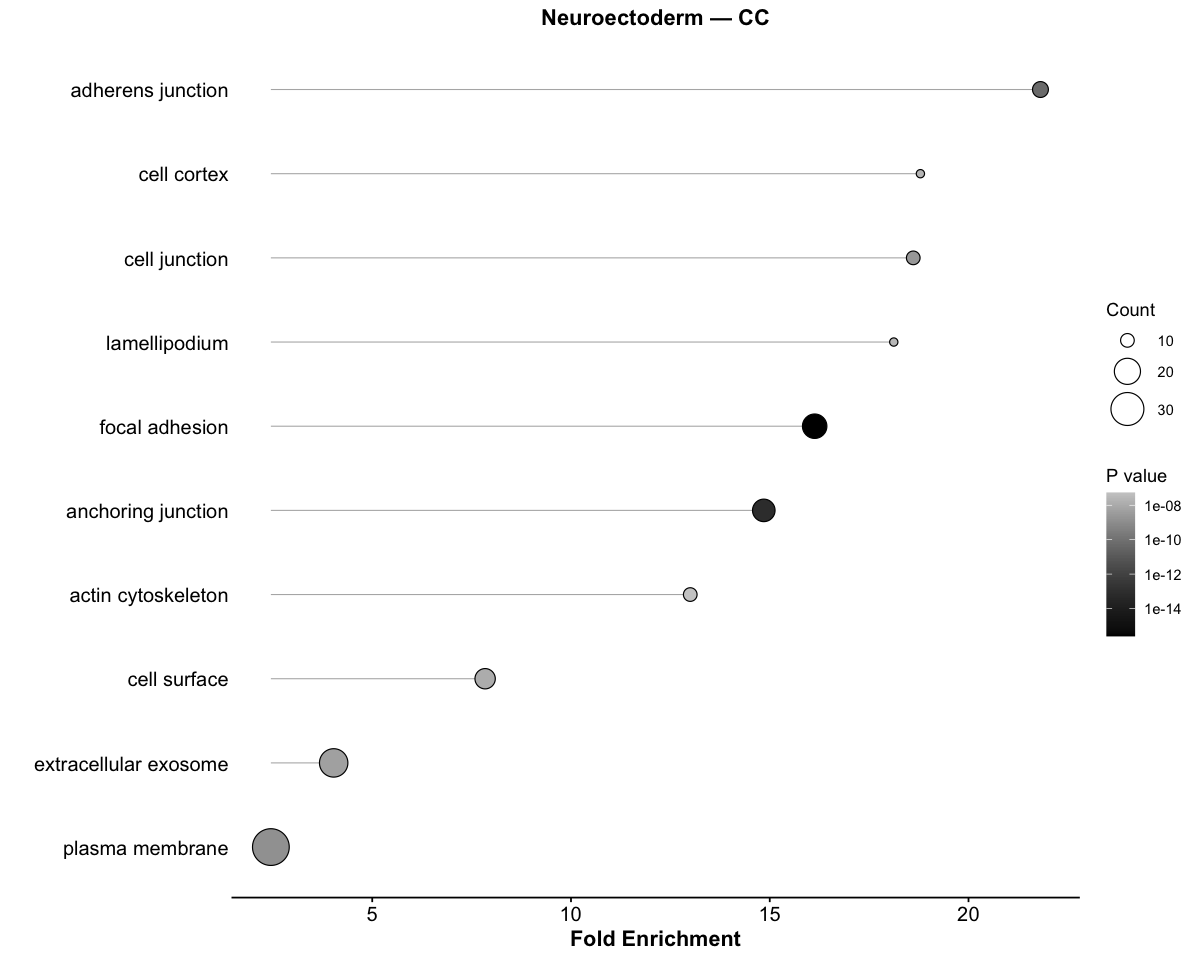

In [92]:
options(repr.plot.width = 10, repr.plot.height = 8)

print(plots[["Neuroectoderm CC"]])



## Using clusterProfiler for Gene Enrichment Analysis

In [96]:
# Convert gene symbols to Entrez IDs and run GO enrichment per cell type:

go_results <- list()

for (ct in names(all_markers)) {
  genes <- all_markers[[ct]]$gene
  
  if (length(genes) < 3) next  # skip cell types with too few genes
  
  # Convert symbols to Entrez IDs
  gene_ids <- bitr(genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
  
  if (nrow(gene_ids) < 3) next
  
  # Run GO enrichment (Biological Process)
  go <- enrichGO(
    gene = gene_ids$ENTREZID,
    OrgDb = org.Hs.eg.db,
    ont = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff = 0.05,
    readable = TRUE
  )
  
  if (!is.null(go) && nrow(go) > 0) {
    go_results[[ct]] <- go
  }
}


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“1.47% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



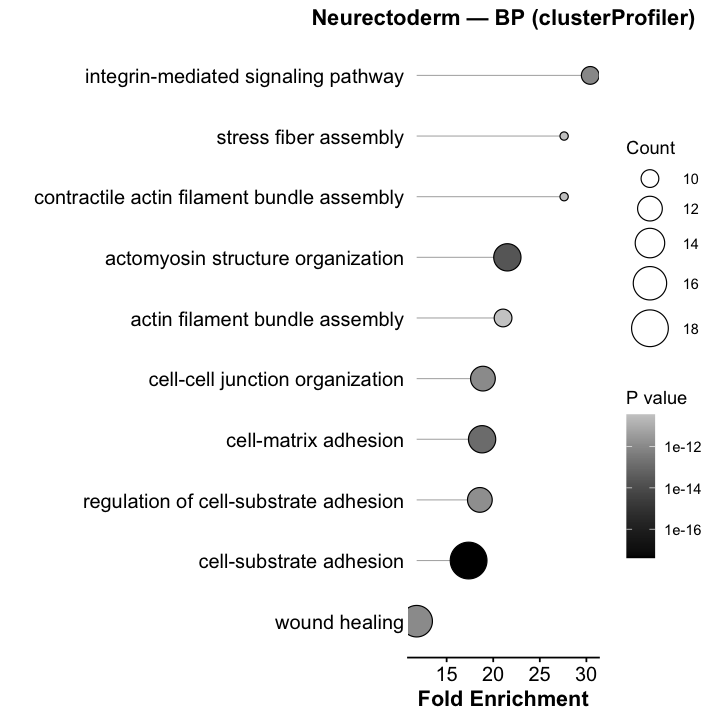

In [97]:
ne_bp <- as.data.frame(go_results[["Neurectoderm"]]) %>%
  filter(Count >= 3) %>%
  head(10) %>%
  mutate(Description = reorder(Description, FoldEnrichment))

ggplot(ne_bp, aes(x = FoldEnrichment, y = Description)) +
  geom_segment(aes(x = min(FoldEnrichment), xend = FoldEnrichment, y = Description, yend = Description),
               color = "grey70", linewidth = 0.3) +
  geom_point(aes(size = Count, fill = pvalue), shape = 21, color = "black", stroke = 0.5) +
  scale_fill_gradientn(colors = c("black", "grey80"), trans = "log10", name = "P value") +
  scale_size_continuous(range = c(2, 10), name = "Count") +
  guides(size = guide_legend(order = 1), fill = guide_colorbar(order = 2)) +
  labs(x = "Fold Enrichment", y = "", title = "Neurectoderm — BP (clusterProfiler)") +
  theme_classic() +
  theme(
    axis.text.y = element_text(size = 12),
    axis.text.x = element_text(size = 12),
    axis.title = element_text(face = "bold", size = 13),
    axis.line.y = element_blank(),
    axis.ticks.y = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )


In [ ]:
go_cc_results <- list()

for (ct in names(all_markers)) {
  genes <- all_markers[[ct]]$gene
  
  if (length(genes) < 3) next
  
  gene_ids <- bitr(genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
  
  if (nrow(gene_ids) < 3) next
  
  go <- enrichGO(
    gene = gene_ids$ENTREZID,
    OrgDb = org.Hs.eg.db,
    ont = "CC",
    pAdjustMethod = "BH",
    pvalueCutoff = 0.05,
    readable = TRUE
  )
  
  if (!is.null(go) && nrow(go) > 0) {
    go_cc_results[[ct]] <- go
  }
}


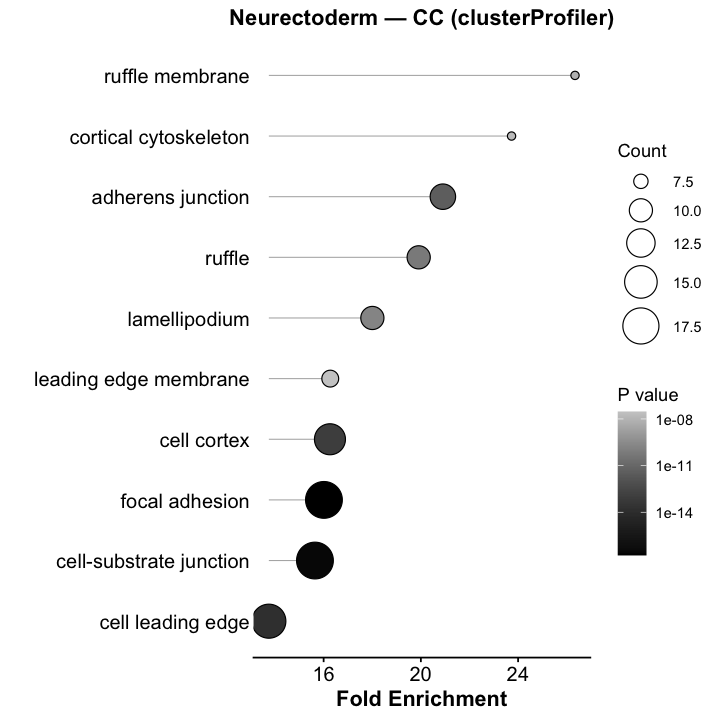

In [98]:
ne_cc <- as.data.frame(go_cc_results[["Neurectoderm"]]) %>%
  filter(Count >= 3) %>%
  head(10) %>%
  mutate(Description = reorder(Description, FoldEnrichment))

ggplot(ne_cc, aes(x = FoldEnrichment, y = Description)) +
  geom_segment(aes(x = min(FoldEnrichment), xend = FoldEnrichment, y = Description, yend = Description),
               color = "grey70", linewidth = 0.3) +
  geom_point(aes(size = Count, fill = pvalue), shape = 21, color = "black", stroke = 0.5) +
  scale_fill_gradientn(colors = c("black", "grey80"), trans = "log10", name = "P value") +
  scale_size_continuous(range = c(2, 10), name = "Count") +
  guides(size = guide_legend(order = 1), fill = guide_colorbar(order = 2)) +
  labs(x = "Fold Enrichment", y = "", title = "Neurectoderm — CC (clusterProfiler)") +
  theme_classic() +
  theme(
    axis.text.y = element_text(size = 12),
    axis.text.x = element_text(size = 12),
    axis.title = element_text(face = "bold", size = 13),
    axis.line.y = element_blank(),
    axis.ticks.y = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )


In [99]:
for (ct in names(go_results)) {
  cat("\n===", ct, "===\n")
  df <- as.data.frame(go_results[[ct]])[1:10, ]
  print(df %>% select(Description, GeneRatio, FoldEnrichment))
}



=== Neurectoderm ===


ERROR: Error: unable to find an inherited method for function ‘select’ for signature ‘x = "data.frame"’
